## 0️⃣ Setup — pasang & import


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform

try:
    from xgboost import XGBRegressor
    ADA_XGB = True
except ImportError:
    ADA_XGB = False
    print("xgboost belum ada — bagian XGBoost akan dilewati. Pasang dengan pip di sel atas.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
print("Setup selesai ✓")

Setup selesai ✓


## 1️⃣ Muat data


In [2]:
df = pd.read_csv("/content/mobil_bekas.csv")
print("Bentuk:", df.shape)
df.head()

Bentuk: (4530, 9)


,merek,model,tahun,transmisi,bahan_bakar,kilometer,warna,lokasi,harga
0,Daihatsu,Sigra,2022,Manual,Bensin,47055.0,Biru,Yogyakarta,104500000
1,Toyota,Innova,2017,Manual,Bensin,71386.0,Merah,Surabaya,144300000
2,Toyota,Yaris,2020,Manual,Bensin,38447.0,Abu-abu,Surabaya,149600000
3,Daihatsu,Terios,2009,Automatic,NaN,NaN,NaN,Medan,29300000
4,Mitsubishi,Pajero Sport,2016,Automatic,Bensin,140859.0,Putih,Makassar,197000000


## 2️⃣ EDA — kenali datamu sebelum menyentuh model

Tujuan: paham bentuk, tipe, nilai bolong, dan **distribusi target**. Jangan skip — 80% keputusan bagus lahir di sini.

In [3]:
# Ringkasan struktur
df.info()
print("\n--- Statistik numerik ---")
display(df.describe())
print("\n--- Nilai unik kolom kategori ---")
for c in df.select_dtypes(include="object").columns:
    print(f"{c}: {df[c].nunique()} unik → {df[c].unique()[:8]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4530 entries, 0 to 4529
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   merek        4530 non-null   object 
 1   model        4530 non-null   object 
 2   tahun        4530 non-null   int64  
 3   transmisi    4440 non-null   object 
 4   bahan_bakar  4395 non-null   object 
 5   kilometer    4348 non-null   float64
 6   warna        4257 non-null   object 
 7   lokasi       4530 non-null   object 
 8   harga        4530 non-null   int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 318.6+ KB

--- Statistik numerik ---


,tahun,kilometer,harga
count,4530.000000,4348.000000,4.530000e+03
mean,2015.488300,133978.092456,1.394258e+08
std,5.131864,77988.877630,4.943015e+08
min,2008.000000,-5000.000000,0.000000e+00
25%,2011.000000,69401.000000,4.082500e+07
50%,2015.000000,124768.500000,7.995000e+07
75%,2020.000000,188282.250000,1.522750e+08
max,2099.000000,478175.000000,2.153000e+10



--- Nilai unik kolom kategori ---
merek: 8 unik → ['Daihatsu' 'Toyota' 'Mitsubishi' 'BMW' 'Honda' 'Mercedes-Benz' 'Suzuki'
 'Nissan']
model: 36 unik → ['Sigra' 'Innova' 'Yaris' 'Terios' 'Pajero Sport' 'Seri 3' 'Rush'
 'Fortuner']
transmisi: 4 unik → ['Manual' 'Automatic' nan 'MT' 'Matic']
bahan_bakar: 2 unik → ['Bensin' nan 'Diesel']
warna: 6 unik → ['Biru' 'Merah' 'Abu-abu' nan 'Putih' 'Hitam' 'Silver']
lokasi: 8 unik → ['Yogyakarta' 'Surabaya' 'Medan' 'Makassar' 'Semarang' 'Bali' 'Jakarta'
 'Bandung']


In [4]:
# Nilai bolong (missing)
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]
print("Kolom dengan nilai bolong:")
print(miss if len(miss) else "  (tidak ada)")
print("\nDuplikat baris:", df.duplicated().sum())

Kolom dengan nilai bolong:
warna          273
kilometer      182
bahan_bakar    135
transmisi       90
dtype: int64

Duplikat baris: 30


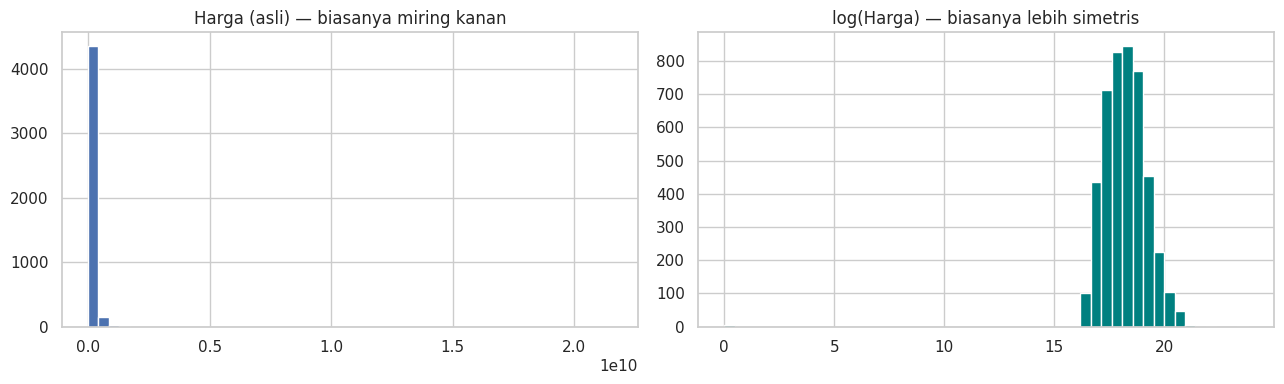

Skewness harga asli : 33.83
Skewness log(harga) : -4.12


In [5]:
# === DISTRIBUSI TARGET (paling penting!) ===
TARGET = "harga"   # SESUAIKAN

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df[TARGET].hist(bins=50, ax=ax[0]); ax[0].set_title("Harga (asli) — biasanya miring kanan")
np.log1p(df[TARGET]).hist(bins=50, ax=ax[1], color="teal"); ax[1].set_title("log(Harga) — biasanya lebih simetris")
plt.tight_layout(); plt.show()

print("Skewness harga asli :", round(df[TARGET].skew(), 2))
print("Skewness log(harga) :", round(np.log1p(df[TARGET]).skew(), 2))
# Kalau log jauh lebih simetris → kita latih model pada log(harga). Catat keputusan ini!


hasil EDA nya: Harga asli sangat right-skewed (33.83). Transformasi log mengubah arah kemiringan menjadi left-skewed (-4.12), sehingga log memang mengurangi masalah right-skew tetapi belum menghasilkan distribusi yang benar-benar simetris. Sebelum memutuskan menggunakan log(harga), perlu diperiksa outlier dan nilai harga ekstrem.

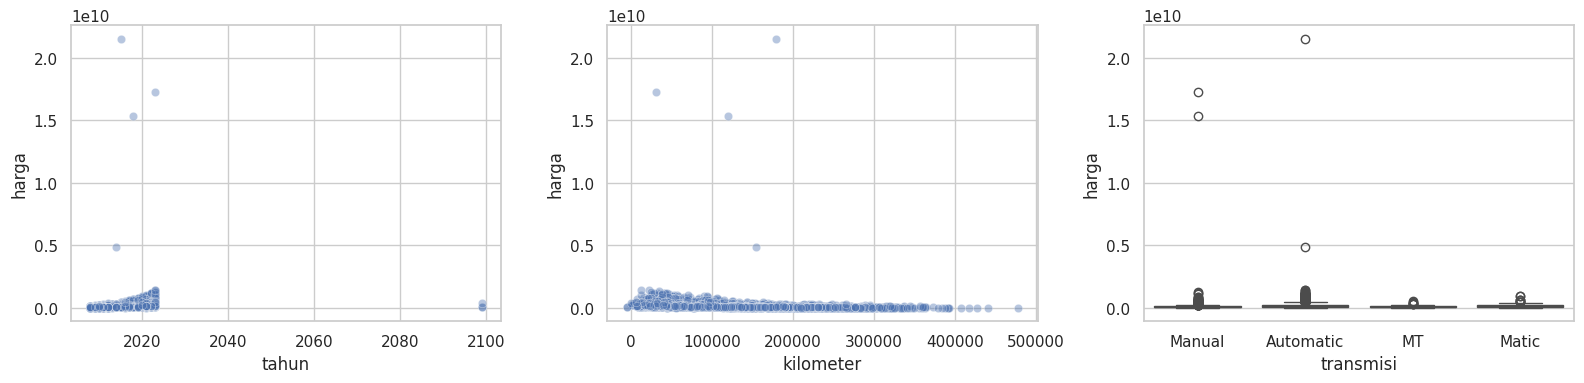

In [6]:
# Hubungan fitur kunci dengan harga
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=df, x="tahun", y=TARGET, alpha=0.4, ax=ax[0])       # SESUAIKAN
sns.scatterplot(data=df, x="kilometer", y=TARGET, alpha=0.4, ax=ax[1])   # SESUAIKAN
sns.boxplot(data=df, x="transmisi", y=TARGET, ax=ax[2])                  # SESUAIKAN
plt.tight_layout(); plt.show()
# Ekspektasi: tahun↑ harga↑, kilometer↑ harga↓, matic vs manual beda.

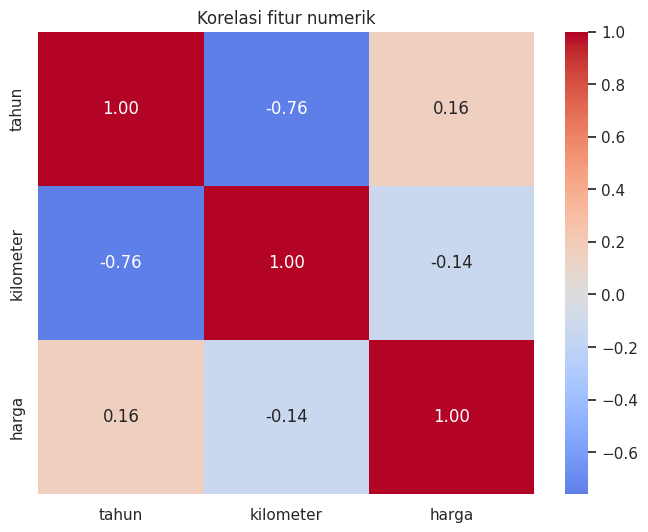

In [7]:
# Korelasi antar fitur numerik
num = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi fitur numerik"); plt.show()

## 3️⃣ Pembersihan data

Perbaiki masalah yang ketemu di EDA: duplikat, satuan salah, outlier absurd (harga Rp 0 / Rp 1 M triliun akibat typo), rentang tak masuk akal (tahun 2050, km negatif).

> ⚠️ **Anti-leakage:** kalau menghapus outlier berdasarkan statistik (mis. IQR), idealnya lakukan **setelah split** atau berbasis aturan domain, bukan dari statistik seluruh data.

In [8]:
df = df.drop_duplicates().copy()

# Buang baris dengan target kosong/absurd (harga wajib ada & masuk akal)
df = df[df[TARGET].notna()]
df = df[(df[TARGET] > 1_000_000) & (df[TARGET] < 5_000_000_000)]   # SESUAIKAN rentang wajar
# Rentang domain masuk akal
df = df[(df["tahun"] >= 1990) & (df["tahun"] <= 2025)]              # SESUAIKAN
df = df[df["kilometer"].between(0, 1_000_000)]                       # SESUAIKAN

print("Bentuk setelah pembersihan:", df.shape)

df["transmisi"] = df["transmisi"].replace({
    "MT": "Manual",
    "Matic": "Automatic"
})

Bentuk setelah pembersihan: (4309, 9)


## 4️⃣ Feature engineering — racik fitur baru

Pengetahuan domain jadi fitur. Contoh untuk mobil:
- **`umur`** = tahun_sekarang − tahun (lebih intuitif dari 'tahun mentah')
- **`km_per_tahun`** = kilometer / umur (mobil km rendah tapi tua ≠ km rendah tapi baru)


In [9]:
TAHUN_SEKARANG = 2026
df["umur"] = TAHUN_SEKARANG - df["tahun"]
df["umur"] = df["umur"].clip(lower=0)
df["km_per_tahun"] = df["kilometer"] / df["umur"].replace(0, 1)

# (opsional) rapikan kategori langka jadi 'Lainnya' biar one-hot nggak meledak
for c in ["merek", "model"]:                     # SESUAIKAN
    if c in df.columns:
        top = df[c].value_counts().nlargest(20).index
        df[c] = df[c].where(df[c].isin(top), "Lainnya")

df[["umur", "km_per_tahun"]].describe()

,umur,km_per_tahun
count,4309.000000,4309.000000
mean,10.583430,12256.716800
std,4.653232,3857.726286
min,3.000000,166.666667
25%,7.000000,9701.000000
50%,11.000000,12315.071429
75%,15.000000,14937.666667
max,18.000000,26565.277778


## 5️⃣ Split train/test — segel test set di awal

Test set dibuka **sekali** di akhir. Semua tuning cuma di train (via CV). Ini disiplin anti-bocor dari Materi 7.

**Keputusan target:** kalau EDA menunjukkan log jauh lebih simetris, kita latih pada `log1p(harga)` lalu balikkan dengan `expm1` saat evaluasi (biar metrik dilaporkan dalam Rupiah asli).

In [10]:
FITUR = [c for c in df.columns if c != TARGET]
X = df[FITUR]
y = df[TARGET]

PAKAI_LOG = True   # set sesuai temuan EDA
y_model = np.log1p(y) if PAKAI_LOG else y

X_train, X_test, y_train, y_test = train_test_split(
    X, y_model, test_size=0.2, random_state=RANDOM_STATE
)
# y_test di sini dalam skala model (log). Simpan versi Rupiah untuk laporan:
y_test_rupiah = np.expm1(y_test) if PAKAI_LOG else y_test
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (3447, 10) | Test: (862, 10)


## 6️⃣ Baseline — lawan yang harus dikalahkan

Sebelum model canggih, ukur model 'bodoh' (selalu tebak rata-rata). Kalau model kerenmu nggak jauh lebih baik dari ini, ada yang salah. Baseline = konteks buat semua angka nanti.

In [11]:
def lapor(nama, y_true_rupiah, y_pred_model):
    """Terima prediksi skala model, balikkan ke Rupiah, cetak metrik."""
    y_pred_rupiah = np.expm1(y_pred_model) if PAKAI_LOG else y_pred_model
    mae  = mean_absolute_error(y_true_rupiah, y_pred_rupiah)
    rmse = np.sqrt(mean_squared_error(y_true_rupiah, y_pred_rupiah))
    r2   = r2_score(y_true_rupiah, y_pred_rupiah)
    print(f"{nama:22s} | MAE: Rp{mae:,.0f} | RMSE: Rp{rmse:,.0f} | R2: {r2:.3f}")
    return {"nama": nama, "MAE": mae, "RMSE": rmse, "R2": r2}

hasil = []
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
hasil.append(lapor("Baseline (rata-rata)", y_test_rupiah, dummy.predict(X_test)))

Baseline (rata-rata)   | MAE: Rp87,304,533 | RMSE: Rp163,372,100 | R2: -0.098


## 7️⃣ Pipeline preprocessing + model

ColumnTransformer (Materi 5) → model (Materi 2/3). Semua dalam satu Pipeline anti-bocor (Materi 8). Kita coba beberapa model dan bandingkan lewat cross-validation.

In [12]:
kolom_num = X.select_dtypes(include=[np.number]).columns.tolist()
kolom_kat = X.select_dtypes(include="object").columns.tolist()
print("Numerik:", kolom_num)
print("Kategori:", kolom_kat)

prep = ColumnTransformer([
    ("num", Pipeline([("isi", SimpleImputer(strategy="median")),
                      ("skala", StandardScaler())]), kolom_num),
    ("cat", Pipeline([("isi", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), kolom_kat),
])

Numerik: ['tahun', 'kilometer', 'umur', 'km_per_tahun']
Kategori: ['merek', 'model', 'transmisi', 'bahan_bakar', 'warna', 'lokasi']


In [13]:
def buat_pipe(model):
    return Pipeline([("prep", prep), ("model", model)])

kandidat = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}
if ADA_XGB:
    kandidat["XGBoost"] = XGBRegressor(n_estimators=400, learning_rate=0.1,
                                       max_depth=5, random_state=RANDOM_STATE)

# Bandingkan via CV (skor = R2 pada skala model). Makin tinggi makin baik.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for nama, model in kandidat.items():
    skor = cross_val_score(buat_pipe(model), X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)
    print(f"{nama:20s} | R2 CV: {skor.mean():.3f} ± {skor.std():.3f}")

Linear Regression    | R2 CV: 0.964 ± 0.015
Ridge                | R2 CV: 0.964 ± 0.015
Random Forest        | R2 CV: 0.950 ± 0.017
XGBoost              | R2 CV: 0.959 ± 0.015


STEP 08 — Tuning Ridge

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# 1. Pipeline Ridge
ridge_pipe = buat_pipe(
    Ridge()
)

# 2. Ruang pencarian alpha
ruang_alpha = {
    "model__alpha": loguniform(1e-3, 1e3)
}

# 3. Randomized Search
search_ridge = RandomizedSearchCV(
    estimator=ridge_pipe,
    param_distributions=ruang_alpha,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 4. Tuning hanya menggunakan TRAIN
search_ridge.fit(X_train, y_train)

# 5. Lihat hasil tuning
print("Best params :", search_ridge.best_params_)
print("Best R2 CV  :", search_ridge.best_score_)

# 6. Bandingkan dengan Linear Regression
r2_linear = 0.964

print(f"\nLinear Regression : {r2_linear:.4f}")
print(f"Ridge Tuned       : {search_ridge.best_score_:.4f}")

Best params : {'model__alpha': np.float64(0.1578232781079558)}
Best R2 CV  : 0.9640764313090893

Linear Regression : 0.9640
Ridge Tuned       : 0.9641


## 9️⃣ Evaluasi di test set — buka brankas SEKALI

Sekarang, dan hanya sekarang, kita sentuh test set. Bandingkan dengan baseline. Skor test biasanya sedikit di bawah CV — itu normal & sehat.

Model final (tuned)    | MAE: Rp17,035,379 | RMSE: Rp41,348,773 | R2: 0.930

=== RINGKASAN ===


,MAE,RMSE,R2
nama,,,
Baseline (rata-rata),"Rp87,304,533","Rp163,372,100",-0.098
Model final (tuned),"Rp17,035,379","Rp41,348,773",0.930
Model final (tuned),"Rp17,035,379","Rp41,348,773",0.930


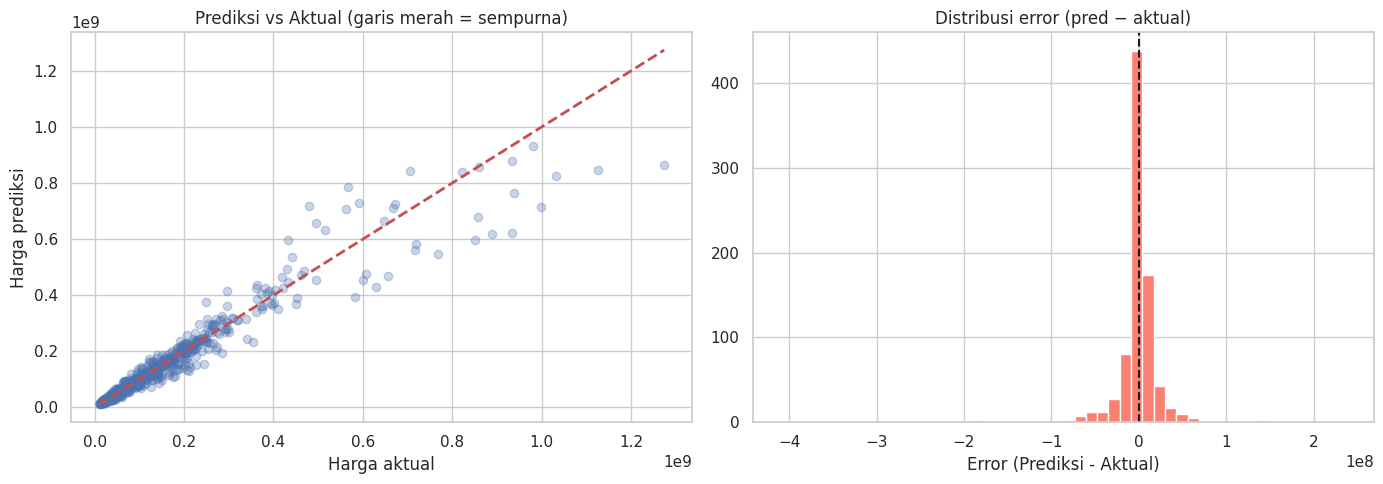

In [16]:
# 7. Ambil model Ridge terbaik
best_ridge = search_ridge.best_estimator_


# ==========================================
# STEP 10 — EVALUASI FINAL DI TEST SET
# ==========================================

# Model final = Ridge hasil tuning
model_final = best_ridge

# Evaluasi model final di TEST SET
hasil.append(
    lapor(
        "Model final (tuned)",
        y_test_rupiah,
        model_final.predict(X_test)
    )
)

# Tampilkan ringkasan
print("\n=== RINGKASAN ===")

display(
    pd.DataFrame(hasil)
    .set_index("nama")
    .style.format({
        "MAE": "Rp{:,.0f}",
        "RMSE": "Rp{:,.0f}",
        "R2": "{:.3f}"
    })
)

# ==========================================
# PREDIKSI TEST DALAM RUPIAH
# ==========================================

pred_model = model_final.predict(X_test)

y_pred_rupiah = (
    np.expm1(pred_model)
    if PAKAI_LOG
    else pred_model
)

# ==========================================
# HITUNG ERROR
# ==========================================

error = y_pred_rupiah - y_test_rupiah

# ==========================================
# VISUALISASI
# ==========================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---- Grafik 1: Prediksi vs Aktual ----
ax[0].scatter(
    y_test_rupiah,
    y_pred_rupiah,
    alpha=0.3
)

lims = [
    y_test_rupiah.min(),
    y_test_rupiah.max()
]

ax[0].plot(
    lims,
    lims,
    "r--",
    lw=2
)

ax[0].set_xlabel("Harga aktual")
ax[0].set_ylabel("Harga prediksi")
ax[0].set_title(
    "Prediksi vs Aktual (garis merah = sempurna)"
)

# ---- Grafik 2: Distribusi Error ----
ax[1].hist(
    error,
    bins=50,
    color="salmon"
)

ax[1].axvline(
    0,
    color="k",
    ls="--"
)

ax[1].set_xlabel("Error (Prediksi - Aktual)")
ax[1].set_title(
    "Distribusi error (pred − aktual)"
)

plt.tight_layout()
plt.show()

## 🔟 Interpretasi — fitur apa yang paling menentukan harga?

Ini yang membedakan 'jalanin kode' dari 'ngerti model'. Recruiter suka bagian ini.

10 fitur paling berpengaruh:
cat__merek_BMW              1.144973
cat__merek_Mercedes-Benz    0.993816
cat__merek_Daihatsu        -0.807943
cat__model_Fortuner         0.645672
cat__merek_Suzuki          -0.562157
cat__model_Agya            -0.559101
cat__model_Brio            -0.550980
cat__model_CR-V             0.483968
cat__model_Calya           -0.470554
cat__model_Terios           0.411535
dtype: float64


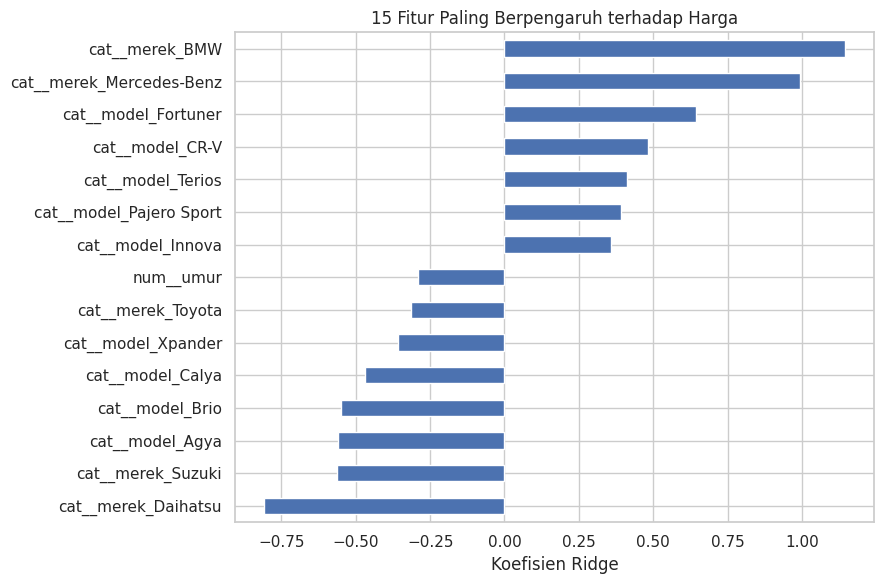

In [17]:
# ==========================================
# STEP 11 — INTERPRETASI MODEL RIDGE
# ==========================================

# Ambil model dan preprocessing dari Pipeline
model_step = model_final.named_steps["model"]
prep_step = model_final.named_steps["prep"]

# Ambil nama fitur setelah preprocessing
nama_fitur = prep_step.get_feature_names_out()

# Ambil koefisien Ridge
koef = pd.Series(
    model_step.coef_,
    index=nama_fitur
)

# Urutkan berdasarkan besar pengaruh absolut
koef_teratas = (
    koef
    .loc[koef.abs().sort_values(ascending=False).index]
)

# Tampilkan 10 fitur teratas
print("10 fitur paling berpengaruh:")
print(koef_teratas.head(10))

# Ambil 15 fitur teratas untuk grafik
top15 = (
    koef_teratas
    .head(15)
    .sort_values()
)

# Plot
plt.figure(figsize=(9, 6))
top15.plot.barh()

plt.title("15 Fitur Paling Berpengaruh terhadap Harga")
plt.xlabel("Koefisien Ridge")
plt.tight_layout()
plt.show()

## 1️⃣1️⃣ Simpan model — joblib (Materi 8)

Bekukan pipeline utuh jadi .pkl + catat versi library (jebakan joblib!).

In [21]:
# ==========================================
# STEP 12 — SIMPAN MODEL
# ==========================================

import joblib

# 1. Simpan Pipeline model final
joblib.dump(
    model_final,
    "model_harga_mobil.pkl"
)

# 2. Catat versi library
import sklearn

baris = [
    f"scikit-learn=={sklearn.__version__}",
    f"pandas=={pd.__version__}",
    f"numpy=={np.__version__}",
]



# 4. Simpan requirements.txt
with open("requirements.txt", "w") as f:
    f.write("\n".join(baris) + "\n")

# 5. Informasi hasil
print(
    "Tersimpan: "
    "model_harga_mobil.pkl + requirements.txt ✓"
)

if PAKAI_LOG:
    print(
        "CATATAN: model dilatih pada log(harga). "
        "Gunakan expm1() setelah predict."
    )
else:
    print(
        "CATATAN: model dilatih pada harga asli."
    )

Tersimpan: model_harga_mobil.pkl + requirements.txt ✓
CATATAN: model dilatih pada log(harga). Gunakan expm1() setelah predict.
